# Part 2: Data Cleaning with Pandas — Youth Unemployment (World Bank)

Welcome back! This notebook is **beginner-friendly** and contains the **talking script** in markdown plus **Python code cells** you can run while recording your video.

**Goal:** Clean the youth unemployment dataset so it’s ready for analysis and modeling.

**Starting file:** `youth_unemployment_long_clean.csv` (saved at the end of Part 1)

### What we'll do
1) Load the long-format CSV
2) Inspect data types and missing values
3) Rename columns (short, consistent names)
4) Handle missing values (ffill/bfill per country)
5) Remove duplicates
6) Validate ranges (0–100%) + optional outlier handling
7) Save the final cleaned file

## 1) Load the Cleaned Long-Format Data
**Talking points:**
- We load the CSV we created in Part 1: `youth_unemployment_long_clean.csv`.
- It already has three key columns: `Country Name`, `Country Code`, `Year`, and `Youth_Unemployment`.
- In real projects, your data may come from Excel/CSV/DB/API, but the Pandas workflow is similar.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True

path = 'youth_unemployment_long_clean.csv'  # produced in Part 1
df = pd.read_csv(path)
print('Loaded shape:', df.shape)
df.head()

Loaded shape: (7981, 4)


,Country Name,Country Code,Year,Youth_Unemployment
0,Africa Eastern and Southern,AFE,1991,15.358171
1,Afghanistan,AFG,1991,10.312000
2,Africa Western and Central,AFW,1991,7.481249
3,Angola,AGO,1991,39.921000
4,Albania,ALB,1991,15.974000


## 2) Inspect the Data
**Talking points:**
- `.info()` shows column names and data types.
- `.isna().sum()` shows how many missing values we have.
- This quick check helps us choose the right cleaning strategy.

In [3]:
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7981 entries, 0 to 7980
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country Name        7981 non-null   object 
 1   Country Code        7981 non-null   object 
 2   Year                7981 non-null   int64  
 3   Youth_Unemployment  7981 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 249.5+ KB


Country Name          0
Country Code          0
Year                  0
Youth_Unemployment    0
dtype: int64

## 3) Rename Columns (Short & Consistent)
**Talking points:**
- Short names make code easier to read and type.
- We'll rename: `Country Name` → `country`, `Country Code` → `country_code`, `Year` → `year`, `Youth_Unemployment` → `youth_unemp`.

In [4]:
df = df.rename(columns={
    'Country Name': 'country',
    'Country Code': 'country_code',
    'Year': 'year',
    'Youth_Unemployment': 'youth_unemp'
})
df.head(3)

,country,country_code,year,youth_unemp
0,Africa Eastern and Southern,AFE,1991,15.358171
1,Afghanistan,AFG,1991,10.312000
2,Africa Western and Central,AFW,1991,7.481249


## 4) Handle Missing Values (Per Country)
**Talking points:**
- Global development data often has gaps.
- For time series per country, a common approach is **forward fill** then **backward fill** within each country.
- This uses the closest available data instead of dropping rows.

In [5]:
df = df.sort_values(['country','year'])
df['youth_unemp'] = (
    df.groupby('country')['youth_unemp']
      .transform(lambda s: s.ffill().bfill())
)
df.isna().sum()

country         0
country_code    0
year            0
youth_unemp     0
dtype: int64

## 5) Remove Duplicates
**Talking points:**
- Duplicates can bias your analysis.
- We’ll drop exact duplicate rows if any exist.

In [6]:
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f'Dropped {before - after} duplicate rows')

Dropped 0 duplicate rows


## 6) Validate Ranges (0–100%) + Optional Outlier Handling
**Talking points:**
- Youth unemployment is a **percentage**, so values should be between **0 and 100**.
- If anything is outside this range, it’s likely an error. We'll clip or filter them.
- You can also inspect distribution or visualize for sanity checks.

In [7]:
print('Min/Max before bounds check:', df['youth_unemp'].min(), df['youth_unemp'].max())
# Keep only sensible percentage range
df = df[(df['youth_unemp'] >= 0) & (df['youth_unemp'] <= 100)]
print('Min/Max after bounds check:', df['youth_unemp'].min(), df['youth_unemp'].max())

Min/Max before bounds check: 0.295 82.409
Min/Max after bounds check: 0.295 82.409


### (Optional) Quick Distribution Check

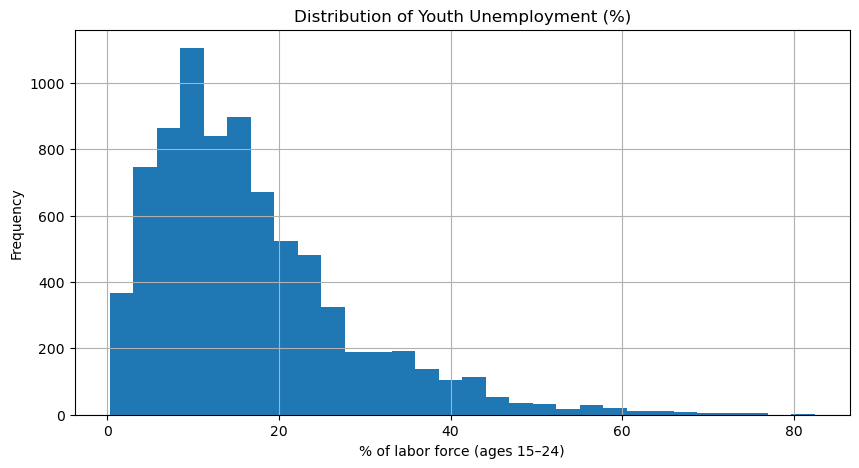

In [8]:
df['youth_unemp'].hist(bins=30)
plt.title('Distribution of Youth Unemployment (%)')
plt.xlabel('% of labor force (ages 15–24)')
plt.ylabel('Frequency')
plt.show()

## 7) Save Final Cleaned File
**Talking points:**
- This file is now **model-ready** for Part 3 (time-series ML).
- We'll save it as `youth_unemployment_cleaned_final.csv`.

In [9]:
out_path = 'youth_unemployment_cleaned_final.csv'
df.to_csv(out_path, index=False)
print(f'Saved final cleaned dataset → {out_path}')

Saved final cleaned dataset → youth_unemployment_cleaned_final.csv


---
### ✅ Recap
- Inspected and renamed columns for readability
- Filled missing values per country (ffill/bfill)
- Removed duplicates and validated the 0–100% range
- Saved a final cleaned dataset for **Part 3: Time-Series ML**

Great work! 🎉